In [1]:
import matplotlib.pyplot as plt
import csv
import json
import numpy as np
def get_APD(voltage, dt,APD_percentage = 0.1): # lib is 2D array, each row is a time series of one pixel
    def linear_interpolation(y0,y1,x0,x1,x):
        
        return (y0 * (x1-x) + y1 * (x-x0)) / (x1-x0)
    APD_percentage = APD_percentage * (max(voltage) - min(voltage)) + min(voltage)
    APD_start_point = None
    APD_end_point = None
    start_apd = False
    APD_value = 0
    APD_start_error = -100
    APD_end_error = -100
    for j in range(len(voltage)):


        if start_apd == False and voltage[j] > APD_percentage:
            start_apd = True
            if j == 0:
                APD_start_error = 0
            else:
                APD_start_error = linear_interpolation(1,0,voltage[j],voltage[j-1],APD_percentage)
                APD_start_error = 1 - APD_start_error
            APD_start_point = j - 1 + APD_start_error
        if start_apd == True and voltage[j] <= APD_percentage: 
            start_apd = False
            APD_end_error = linear_interpolation(0,-1,voltage[j],voltage[j-1],APD_percentage)
            APD_end_point = j + APD_end_error
            APD_value += (APD_start_error + APD_end_error) * dt                
            APD_start_error = -100
            APD_end_error = -100
        if start_apd == True:
            APD_value += dt
    return APD_value,[APD_start_point,APD_end_point]
def get_dvdt_max_and_plateau_duration(voltage,dt):
    dvdt_max = -1e6
    dvdt_plateau_lower_bound = -0.350
    plateau_duration = 0
    plateau_end_idx = None
    for j in range(1,len(voltage)):
        dvdt = (voltage[j] - voltage[j-1]) / dt
        plateau_duration += dt
        if dvdt > dvdt_max:
            dvdt_max = dvdt
        if dvdt < 0 and j > 100 and dvdt < dvdt_plateau_lower_bound:
            plateau_end_idx = j
            return dvdt_max, plateau_duration, plateau_end_idx
    return dvdt_max, plateau_duration, plateau_end_idx

def get_AP(voltage_signal):
    APs = []
    starting_indexes = []
    current_AP = []
    in_AP = False
    for i in range(1, len(voltage_signal)):
        dv_dt = voltage_signal[i] - voltage_signal[i-1]
        if not in_AP:
            if dv_dt > 0.005 and voltage_signal[i-1] < 0:
                in_AP = True
                current_AP = [voltage_signal[i-1], voltage_signal[i]]
                current_AP_start_idx = i - 1
                starting_indexes.append(current_AP_start_idx)
        else:
            current_AP.append(voltage_signal[i])
            if i + 1 < len(voltage_signal):
                next_dv_dt = voltage_signal[i+1] - voltage_signal[i]
                if next_dv_dt > 0.005 and voltage_signal[i] < 0 and len(current_AP) > 3000:
                    in_AP = False
                    APs.append(current_AP)
                    current_AP = []    
    return APs, starting_indexes

In [2]:
class analyze_population_results:
    def __init__(self,para,nbins,period,csv_file):
        self.para = para
        self.nbins = nbins
        self.period = period
        self.csv_file = csv_file
        self.voltage = {}
        
    def load_voltage(self):
        prev_key = float(-1)
        with open(self.csv_file, 'r') as file:
            reader = csv.reader(file, delimiter=',')
            cur_v = []
            for row in reader:
                if len(row) == 1:
                    key = float(row[0].split('_')[1].replace('ID',''))
                    if prev_key != -1 and prev_key < 300:
                        self.voltage[prev_key] = cur_v
                    prev_key = key
                    continue
                cur_v = [float(v) for v in row if v]
            #voltage[prev_key] = cur_v
        # APD = get_APD(voltage, dt=step, APD_percentage=0.3)
        # read a json file.
        with open (f"./2D-TNNP - Na - pace/population_params_{self.para}_N_{self.nbins}.json") as file:
            parameters = json.load(file)
        parameters = {int(k['id']): {item[0]: round(item[1],2) for item in k.items() if item[0] != 'id'} for k in parameters}
        
    def analyze_biomarkers(self):
        APD_90_lst = []
        plateau_duration_lst = []
        dv_dt_max_lst = []
        v_peak_lst = []
        RMP_lst = []
        dome_peak_lst = []
        for key in sorted(self.voltage.keys()):
            APs, starting_indexes = get_AP(self.voltage[key])
            
            last_AP = APs[-1]
            
            APD_90, APD_points = get_APD(last_AP, dt=0.2, APD_percentage=0.1) # dt=0.2 ms
            dvdt_max, plateau_duration, plateau_end_idx = get_dvdt_max_and_plateau_duration(last_AP, dt=0.2) # dt=0.2 ms
            v_peak = max(last_AP)
            RMP = min(last_AP)
            dome_peak = max(last_AP[np.argmax(last_AP)+10:])
            
            APD_90_lst.append(APD_90)
            plateau_duration_lst.append(plateau_duration)
            dv_dt_max_lst.append(dvdt_max)
            v_peak_lst.append(v_peak)
            RMP_lst.append(RMP)
            dome_peak_lst.append(dome_peak)
            biomarkers = [
                'APD90 (ms)',
                'Plateau Duration (ms)',
                'dV/dt Max (mV/ms)',
                'Vm Peak (mV)',
                'RMP (mV)',
                'Dome Peak (mV)',
            ]
            output = {}
            result = [APD_90_lst, plateau_duration_lst, dv_dt_max_lst, v_peak_lst, RMP_lst, dome_peak_lst]
            for idx,bio in enumerate(biomarkers):
                output[bio] = result[idx]
        return output


para = 12
nbins = 2500
period = 500
Tissue = analyze_population_results(para=12,nbins=2500,period=500,csv_file=rf".\populationTissue_period_{period}_measureTime_40000_C_Na_C_K1_C_to_C_Kr_C_Ks_pKNa_C_CaL_kNaCa_C_pK_C_pCa_C_bNa_C_bCa_300.csv")
Tissue.load_voltage()
Tissue_biomarkers = Tissue.analyze_biomarkers()
Cell = analyze_population_results(para=12,nbins=2500,period=500,csv_file=rf".\populationCell_period_{period}_measureTime_40000_C_Na_C_K1_C_to_C_Kr_C_Ks_pKNa_C_CaL_kNaCa_C_pK_C_pCa_C_bNa_C_bCa_300.csv")
Cell.load_voltage()
Cell_biomarkers = Cell.analyze_biomarkers()

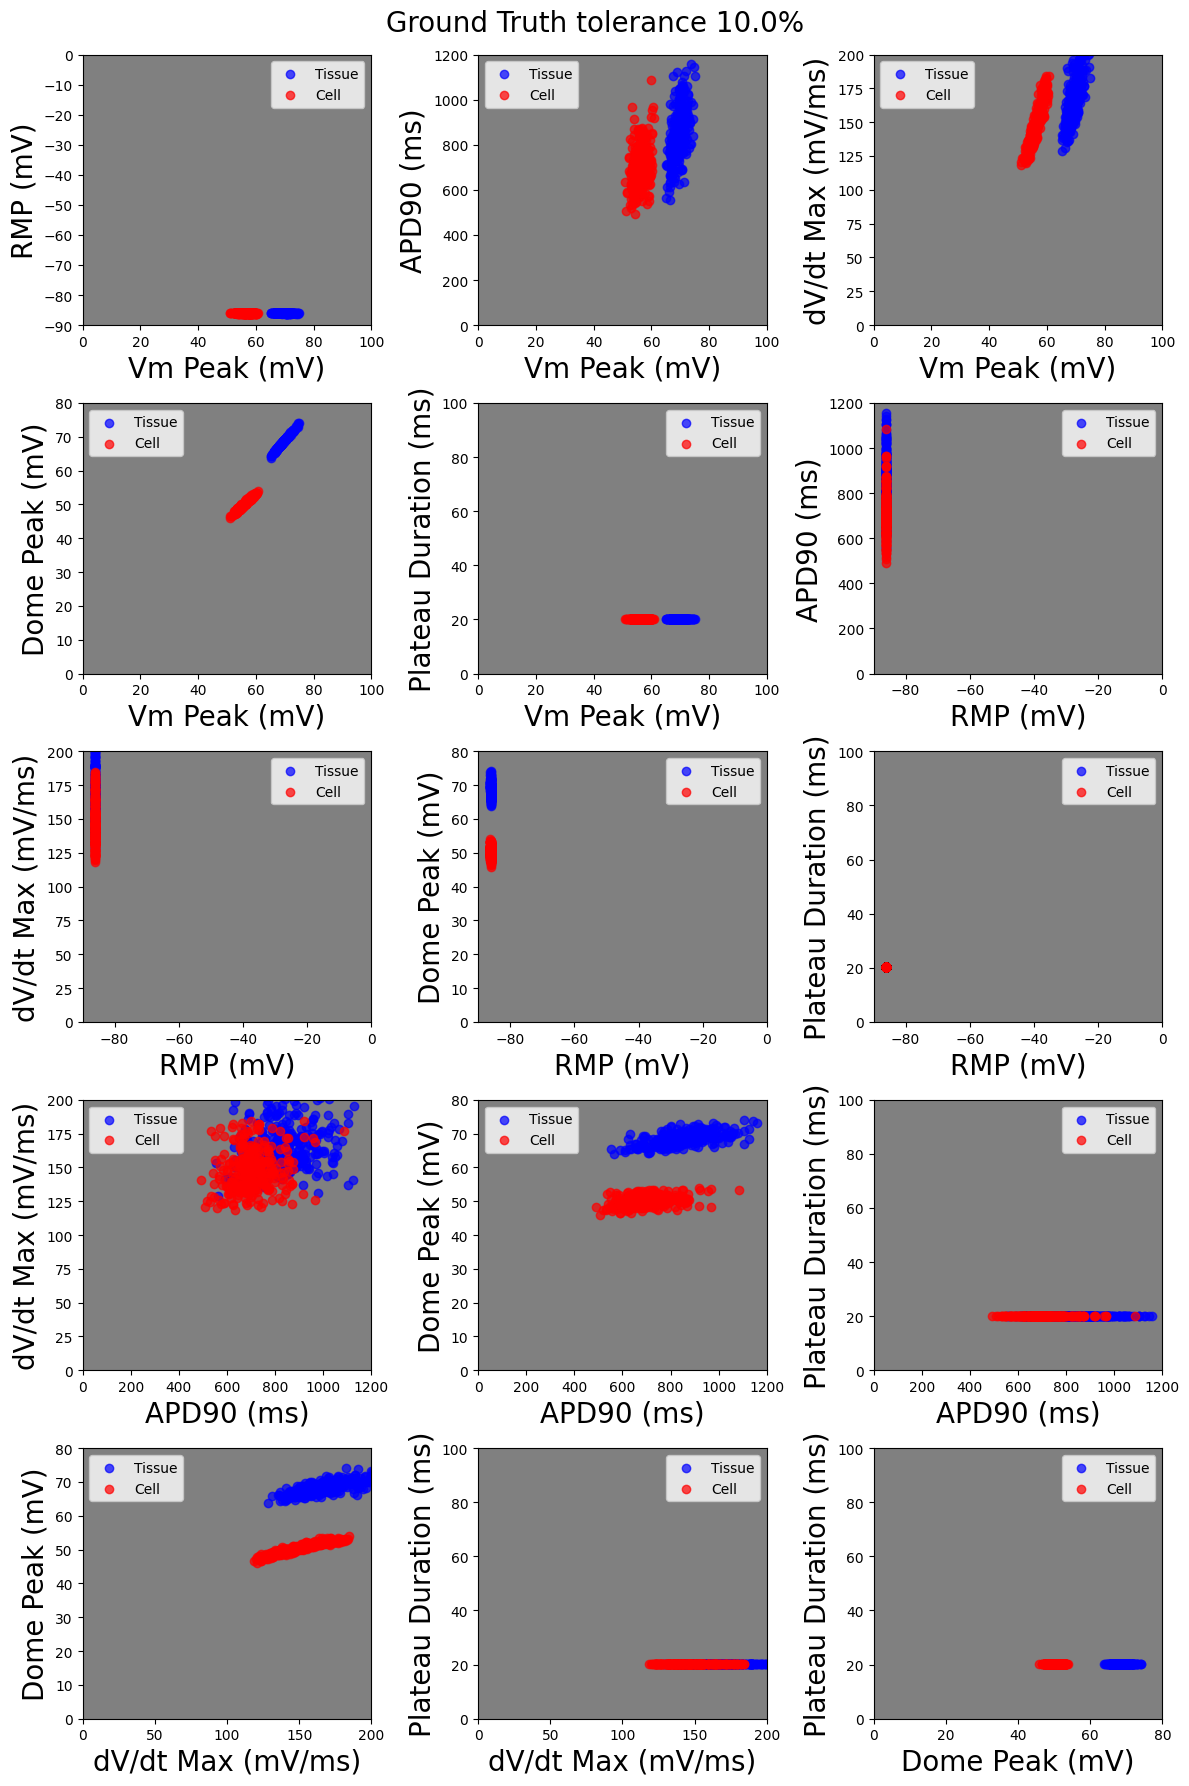

In [3]:
def plot_2d_biomarkers(ax,m1,m2,tolerance,m1_name,m2_name,m1_range=None,m2_range=None,color='black',label=None):
    ax.scatter(m1[1:], m2[1:], alpha=0.7, color=color,label=label)
    ax.legend()
    # also plot ground truth m1[0], m2[0] with 5% error tolerance as vertical and horizontal white lines
    if color == 'black':
        ax.axvline(x=m1[0]*(1+tolerance), color='w', linestyle='--')
        ax.axvline(x=m1[0]*(1-tolerance), color='w', linestyle='--')
        ax.axhline(y=m2[0]*(1+tolerance), color='w', linestyle='--')
        ax.axhline(y=m2[0]*(1-tolerance), color='w', linestyle='--')
    # make the background grey
    ax.set_facecolor('grey')
    ax.set_xlabel(m1_name, fontsize=20)
    ax.set_ylabel(m2_name, fontsize=20)
    ax.margins(0.05)
    
    # set xy range
    if m1_range:
        ax.set_xlim(m1_range)
    if m2_range:
        ax.set_ylim(m2_range)
    
    # besides plot, also filter the point ID within the tolerance and return them
    within_tolerance_ids = [i for i in range(1, len(m1)) if (m1[0]*(1-tolerance) <= m1[i] <= m1[0]*(1+tolerance)) and (m2[0]*(1-tolerance) <= m2[i] <= m2[0]*(1+tolerance))]
    return within_tolerance_ids

biomarkers_range = {
    'APD90 (ms)': (0, 1200),
    'Plateau Duration (ms)': (0, 100),
    'dV/dt Max (mV/ms)': (0, 200),
    'Vm Peak (mV)': (0, 100),
    'RMP (mV)': (-90, 0),
    'Dome Peak (mV)': (0, 80),
}

plot_pairs = [
    # Row 1
    ('Vm Peak (mV)', 'RMP (mV)'),
    ('Vm Peak (mV)', 'APD90 (ms)'),
    ('Vm Peak (mV)', 'dV/dt Max (mV/ms)'),
    # Row 2
    ('Vm Peak (mV)', 'Dome Peak (mV)'),
    ('Vm Peak (mV)', 'Plateau Duration (ms)'),
    ('RMP (mV)', 'APD90 (ms)'),
    # Row 3
    ('RMP (mV)', 'dV/dt Max (mV/ms)'),
    ('RMP (mV)', 'Dome Peak (mV)'),
    ('RMP (mV)', 'Plateau Duration (ms)'),
    # Row 4
    ('APD90 (ms)', 'dV/dt Max (mV/ms)'),
    ('APD90 (ms)', 'Dome Peak (mV)'),
    ('APD90 (ms)', 'Plateau Duration (ms)'),
    # Row 5
    ('dV/dt Max (mV/ms)', 'Dome Peak (mV)'),
    ('dV/dt Max (mV/ms)', 'Plateau Duration (ms)'),
    ('Dome Peak (mV)', 'Plateau Duration (ms)'),
]

tolerance = 0.1
within_tolerance_ids_all = set()

# Create the figure and the 5x3 grid of subplots
fig, axes = plt.subplots(5, 3, figsize=(12, 18))
fig.tight_layout(pad=3.0) # Add padding between subplots

for i, pair in enumerate(plot_pairs):
    r = i // 3
    c = i % 3
    
    m1_name, m2_name = pair
    m1_data = Tissue_biomarkers[m1_name]
    m2_data = Tissue_biomarkers[m2_name]
    
    within_tolerance_ids = plot_2d_biomarkers(axes[r, c], m1_data, m2_data, tolerance, m1_name, m2_name, biomarkers_range[m1_name], biomarkers_range[m2_name],'blue','Tissue')
    within_tolerance_ids_all.update(within_tolerance_ids)
for i, pair in enumerate(plot_pairs):
    r = i // 3
    c = i % 3
    
    m1_name, m2_name = pair
    m1_data = Cell_biomarkers[m1_name]
    m2_data = Cell_biomarkers[m2_name]
    
    within_tolerance_ids = plot_2d_biomarkers(axes[r, c], m1_data, m2_data, tolerance, m1_name, m2_name, biomarkers_range[m1_name], biomarkers_range[m2_name],'red','Cell')
    within_tolerance_ids_all.update(within_tolerance_ids)
#print(within_tolerance_ids_all)
plt.suptitle(f'Ground Truth tolerance {tolerance*100}%', fontsize=20,y=0.99)
plt.tight_layout()
plt.savefig("TNNP_cell_para_Variation_biomarkers_2D.png", dpi=300)
plt.show()



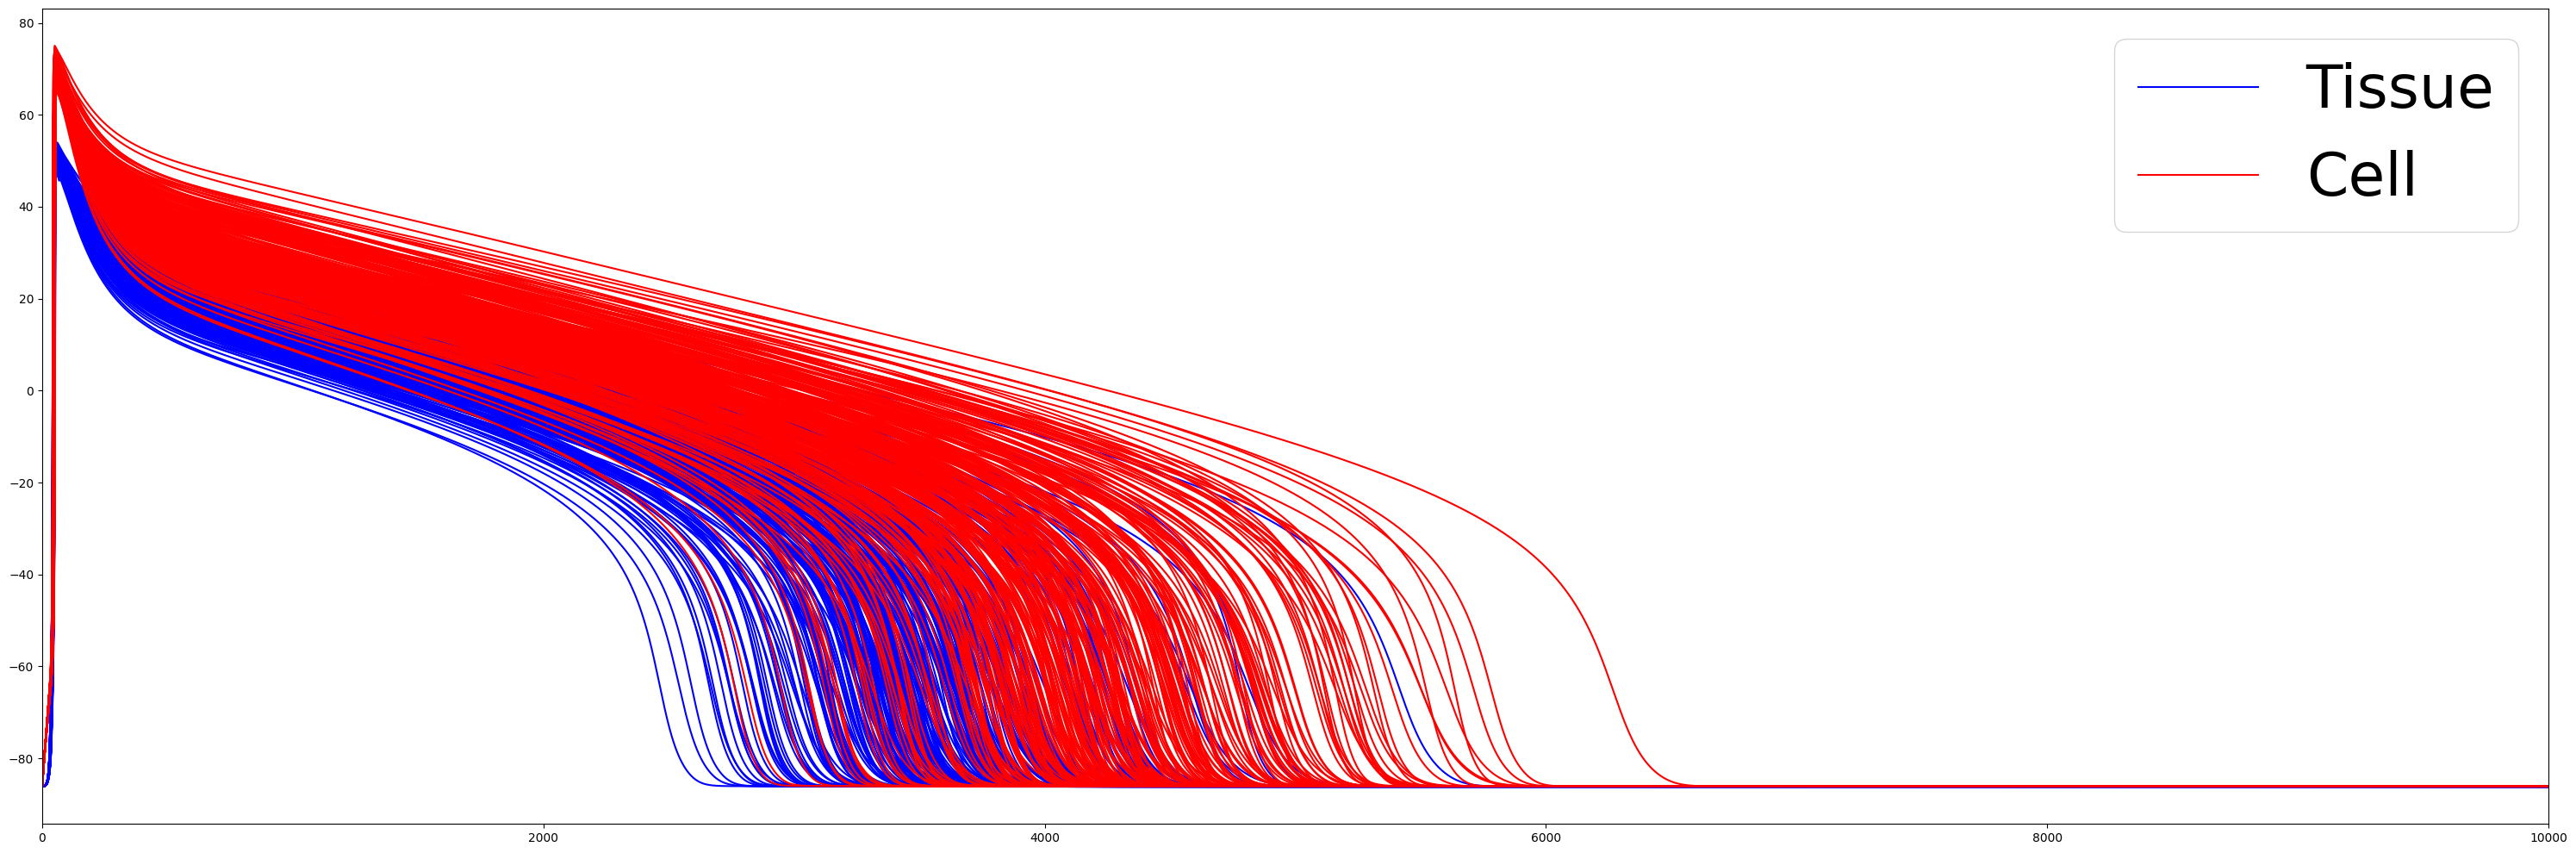

In [5]:
plt.figure(figsize=(30, 10))

# Plot Cell voltage
for i, key in enumerate(sorted(Cell.voltage.keys())):
    APs, starting_indexes = get_AP(Cell.voltage[key])
    last_AP = APs[-1]
    # Only label the first iteration
    label = 'Tissue' if i == 0 else "" 
    plt.plot(last_AP, color='blue', label=label)

# Plot Tissue voltage
for i, key in enumerate(sorted(Tissue.voltage.keys())):
    APs, starting_indexes = get_AP(Tissue.voltage[key])
    last_AP = APs[-1]
    # Only label the first iteration
    label = 'Cell' if i == 0 else "" 
    plt.plot(last_AP, color='red', label=label)
plt.xlim(0, 10000)
plt.legend(fontsize=50,loc='upper right')
plt.tight_layout()
plt.savefig("TNNP_para_AllAPs.png", dpi=300)